**Flux Plots for Different Deployments**

This will try to visualize flux on frying pan shoals over the five deployments.


In [ ]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
plt.rcParams.update({'font.size': 14}) 


deployment_num = [1,2,3]
sensor_spot = ["S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

In [5]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            files = ["DepthAveragedFlowDirection", "DepthAveragedCurrentVelocity", "Vertavg","Echo1avg","Time","Sedtime","DepthAveragedEastVelocity","DepthAveragedNorthVelocity"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity


HDF5ExtError: Internal error reading the elements (H5ARRAYOreadSlice returned errorcode -8)

In [ ]:
#Create lists of what sensors are in each deployment
# 1. Define your categories based on your naming convention
sides = ['S', 'E', 'C']  # South, East, Central
landers = ['0', '1']
deployments = range(1, 6)

# 2. Organize variables into a nested dictionary
# This uses globals() to grab the actual data stored in those variable names
organized_waves = {}

for s in sides:
    for l in landers:
        for d in deployments:
            var_name = f"waves_{s}{l}_{d}"
            
            # Check if this specific combination exists in your workspace
            if var_name in globals():
                if s not in organized_waves: organized_waves[s] = {}
                if l not in organized_waves[s]: organized_waves[s][l] = {}
                
                # Store the data in the dict
                organized_waves[s][l][d] = globals()[var_name]

# Example automative loop 
# for side, lander_dict in organized_waves.items():
#     for lander_id, dep_dict in lander_dict.items():
#         for dep_num, data in dep_dict.items():
print(organized_waves.keys())

dict_keys(['S'])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_orbital_bars(waves, title=None, cmap="viridis"):
    plt.rcParams.update({'font.size': 7}) 

    """
    Polar orbital bar plot.

    Parameters
    ----------
    waves : dict
        Dictionary with keys:
        - DepthAveragedFlowDirection
        - DepthAveragedCurrentVelocity
        - Vertavg

    title : str
        Plot title

    cmap : str
        Matplotlib colormap

    normalize_velocity : bool
        Normalize bar length
    """

    # ----------------------------------
    # Extract data
    # ----------------------------------
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")

    direction = waves["DepthAveragedFlowDirection"].values.squeeze()
    velocity = waves["DepthAveragedCurrentVelocity"].values.squeeze()
    if echo ==True:
        vertavg, mask = despiker(waves["Vertavg"])
    if echo ==False:
        vertavg, mask = despiker(waves["Echo1avg"])
    #Downsample vert avg to match dir and vel length

    if len(vertavg) > len(direction):
        chunks = np.array_split(vertavg, len(direction))
        
        # Map the mean function across those chunks
        vertavg = np.array([np.mean(chunk) for chunk in chunks])

    # ----------------------------------
    # Bin Data into 10 degree bins
    # ----------------------------------
    bins = np.arange(0, 360 + 10, 10)
    bin_indices = np.digitize(direction, bins) - 1  # Get bin
    bin_vertavg = np.array([np.nansum(vertavg[bin_indices == i]) for i in range(len(bins) - 1)])
    bin_theta = np.deg2rad((bins[:-1] + bins[1:]) / 2)  # Bin centers
    bin_width = np.deg2rad(10)  # Bin width
    bin_vel = np.array([np.nanmean(velocity[bin_indices == i]) for i in range(len(bins) - 1)])
    
    bin_vel = np.nan_to_num(bin_vel, nan=0.0)

    # Normalize intensity for color mapping
    bin_vertavg = bin_vertavg / np.nanmax(bin_vertavg)

    # ----------------------------------
    # Colors from Vertavg
    # ----------------------------------

    norm = plt.Normalize(np.nanmin(bin_vertavg), np.nanmax(bin_vertavg))
    cmap = plt.colormaps.get_cmap(cmap)
    colors = cmap(norm(bin_vertavg))

    

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))

    bars = ax.bar(bin_theta, bin_vel, width=bin_width, bottom=0, color=colors, alpha=0.8)
    ax.set_ylim(0,.5)
    
    # ----------------------------------
    # Formatting
    # ----------------------------------

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    if title:
        ax.set_title(title)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.colorbar(sm, ax=ax, label="Normalized Sum of Backscatter Intensity (dB)")
    plt.xlabel("Flow Direction (degrees)")
    plt.ylabel("Depth-Averaged Current Velocity (m/s)", labelpad=40)
    plt.tight_layout()
    plt.show()

In [ ]:
#generate quiver plots

def plot_quiver_ampavg(waves, title=None,echo = False, ylim1 = 30, ylim2 = 80):
    plt.rcParams.update({'font.size': 14}) 
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")
    
    fig,axs = plt.subplots(2, 1, figsize=(14,6), sharex=True)
    v = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.cos(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))
    u = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.sin(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))

    x = waves['Time'].values.squeeze()
    y = np.zeros(x.shape)  # x can be zeros since we are only interested in the direction and magnitude of the vectors

    q = axs[0].quiver(x,y,u,v,waves['DepthAveragedCurrentVelocity'].values.squeeze(), cmap='viridis',scale =7)
    axs[0].quiverkey(q, X=0.9, Y=1.05, U=0.5, label='0.5 m/s', labelpos='E',)
    axs[0].set_title(title + " Current Flow Vectors")
    axs[0].set_xlabel("Time (YY-MM-DD)")
    axs[0].set_ylabel("(South to North)")
    axs[0].set_xlim(waves['Time'].values.squeeze()[0], waves['Time'].values.squeeze()[-24*2])

    if echo == True:
        despiked_vert, mask = despiker(waves["Vertavg"],lam =3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_vert,label= 'Vertical Depth Averaged Amplitude')
        axs[1].set_xlabel("Time (YY-MM-DD)")
        axs[1].set_ylabel("Backscatter Intensity (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(ylim1,ylim2) 
        axs[1].legend()

    if echo == False:
        despiked_echo, mask = despiker(waves["Echo1avg"], lam = 3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_echo,label= 'Echo 1 Depth Averaged Amplitude')
        axs[1].set_xlabel("Time (YY-MM-DD)")
        axs[1].set_ylabel("Backscatter Intensity (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(ylim1, ylim2)
        axs[1].legend()

    axs[0].tick_params(labelbottom=True,labelrotation = 15)
    axs[1].tick_params(labelbottom=True,labelrotation = 15)
    plt.tight_layout()
    plt.show()

**Section to look at Different plots**

Deployment 1 has **TC8**, S1 Lander features strong WSW currents when echo intensity is peaking. 

Deployment 2 has **Small Nor'easters**, S0 Lander features weak N currents when echo intensity is peaking, likely due to tides.

In [ ]:
coefS0, outS01, vel = tidal_ellipse(organized_waves['S']['0'][3]['DepthAveragedEastVelocity'].values.squeeze(), organized_waves['S']['0'][3]['DepthAveragedNorthVelocity'].values.squeeze(),organized_waves['S']['0'][3]['Time'].values.squeeze(), sensor = "S0", dep = "3", constituents="auto")
vel.to_hdf("Z:\llavengood\Mean_Tidal_Flows\S0_3_velocity.h5", key="velocity", mode="w")

u_avg = np.mean(outS01.u)
v_avg = np.mean(outS01.v)

plt.quiver(0, 0, u_avg, v_avg, angles='xy', scale_units='xy', scale=1)

NameError: name 'tidal_ellipse' is not defined

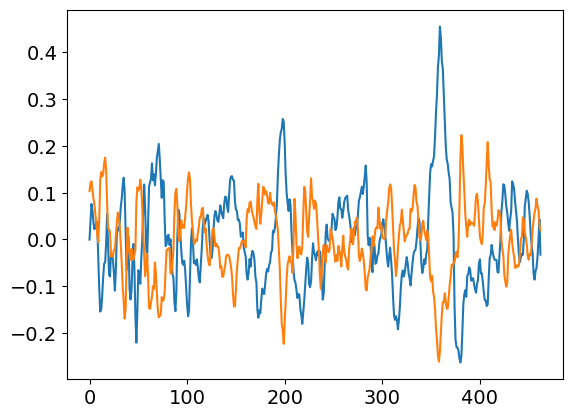

-4.36067720010196e-05
-1.3493635342149431e-05


In [ ]:
plt.plot(vel['U_residual'])
plt.plot(vel['V_residual'])
plt.show()

print(np.nanmean(vel['U_residual']))
print(np.nanmean(vel['V_residual']))

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import cartopy.crs as ccrs

def geoplot(Datadir, filepath, dep=1):
    # Convert dep to string to match filename parsing
    dep_str = str(dep)
    
    # 1. Setup the Map
    src = rasterio.open(filepath)
    img16 = src.read()
    # Basic normalization for 8-bit display
    img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
    
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    ax.imshow(
        img8.transpose(1, 2, 0),
        origin="upper",
        extent=extent, 
        transform=ccrs.PlateCarree()
    )

    # 2. Define Lander Coordinates (Update these with real locations!)
    # Format: "LanderName": (Longitude, Latitude)
    lander_coords = {
    "S0": (-77.942100, 33.730200),
    "S1": (-77.983700, 33.793700),
    "C0": (-77.884083, 33.664683),
    "E0": (-77.900567, 33.738750),
    "E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
    }

    # 3. Process Files
    for filename in os.listdir(Datadir):
        if not filename.endswith(".h5"):
            continue
            
        # Parse filename: Expecting "Lander_Dep_Date..."
        parts = filename.split("_")
        file_lander = parts[0]
        file_dep = parts[1]

        if file_dep == dep_str:
            datapath = os.path.join(Datadir, filename)
            data = pd.read_hdf(datapath, key="velocity")
            
            # Extract velocities
            u = np.nanmean(data['U_residual'].values)
            v = np.nanmean(data['V_residual'].values)
            print(file_lander, u, v)
            # Get coords from dictionary, default to S0 if not found
            lon, lat = lander_coords.get(file_lander, lander_coords["S0"])

            # 4. Plot Vector
            q = ax.quiver(
                lon, lat, u, v,
                transform=ccrs.PlateCarree(),
                color='black', 
                scale=0.1,      # Adjust based on current speeds
                width=0.005
            )
            # After your q = ax.quiver(...) call
            qk = ax.quiverkey(q, 
                  X=0.15, Y=0.1, # Position on the plot
                  U=0.01,        # The length of the reference arrow (e.g., 0.01 m/s)
                  label='Reference: 0.01 m/s', 
                  labelpos='E')
            
            # Add a label for the lander
            ax.text(lon, lat, file_lander, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right')
            

    # Gridlines and Labels
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
    gl.top_labels = False
    gl.right_labels = False

    plt.title(f"Mean Flows after Tidal Ellipse Removal for Deployment {dep}")
    plt.show()

In [ ]:
# geoplot(r"Z:\llavengood\Mean_Tidal_Flows",r"Z:\deployment_5\2025-08-27-16bitTiff.tiff", dep=1)